# FIAP Tech Challenge — Fase 4
## Modelo LSTM PETR4.SA — v8 corrigida

Esta versão corrige o principal problema da v7: **o conjunto de teste não é mais usado como validação durante o treino**.

Pipeline:

1. Coleta de dados com `yfinance`.
2. Feature engineering sem usar informação futura.
3. Criação de janelas temporais no dataset completo.
4. Split temporal por data-alvo: treino, validação e teste.
5. Treino da LSTM usando apenas treino + validação para early stopping.
6. Avaliação final no teste uma única vez.
7. Comparação com baseline: `próximo fechamento = último fechamento conhecido`.
8. Salvamento do modelo, preprocessing, métricas e metadados.

A saída da LSTM é um **ratio de preço em relação à âncora da janela**. O preço final previsto é reconstruído em R$:

```text
preço previsto = ratio previsto × preço âncora
```

## 1. Imports e configuração

In [1]:
import os
import json
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

# Reprodutibilidade aproximada
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executando em: {DEVICE}")
if DEVICE.type == "cuda":
    print(torch.cuda.get_device_name(0))

Executando em: cuda
NVIDIA GeForce RTX 4070 SUPER


## 2. Hiperparâmetros

A divisão temporal abaixo usa validação separada do teste. O teste só será usado no final.

In [2]:
SYMBOL = "PETR4.SA"
START_DATE = "2018-01-01"

WINDOW_SIZE = 30
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.20
BATCH_SIZE = 32
NUM_EPOCHS = 150
PATIENCE = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0

ARTIFACT_DIR = Path("models/petr4_lstm_v8")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9

## 3. Coleta dos dados e feature engineering

As features são calculadas apenas com dados presentes/passados em cada linha. A previsão para o dia `i` usa uma janela até `i-1`.

In [3]:
def download_data(symbol: str, start_date: str) -> pd.DataFrame:
    import yfinance as yf

    df = yf.download(
        symbol,
        start=start_date,
        interval="1d",
        auto_adjust=False,
        progress=False,
    )

    if df.empty:
        raise ValueError(f"Nenhum dado retornado para {symbol}")

    # yfinance pode retornar MultiIndex dependendo da versão/configuração
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.sort_index().copy()
    df.index = pd.to_datetime(df.index)
    return df


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()

    required = ["Open", "High", "Low", "Close", "Volume"]
    missing = [c for c in required if c not in data.columns]
    if missing:
        raise ValueError(f"Colunas obrigatórias ausentes: {missing}")

    for col in required:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    # Features de preço/tendência
    data["SMA_7"] = data["Close"].rolling(7).mean()
    data["SMA_21"] = data["Close"].rolling(21).mean()

    # Features estacionárias/relativas
    data["Log_Return"] = np.log(data["Close"] / data["Close"].shift(1))
    data["Volatility_21"] = data["Log_Return"].rolling(21).std()
    data["Momentum_5"] = data["Close"] / data["Close"].shift(5) - 1.0
    data["Range_Pct"] = (data["High"] - data["Low"]) / data["Close"]
    data["Volume_Z"] = (
        (data["Volume"] - data["Volume"].rolling(21).mean())
        / data["Volume"].rolling(21).std()
    )

    data = data.replace([np.inf, -np.inf], np.nan).dropna()
    data = data.loc[data["Volume"] > 0].copy()
    return data


df_raw = download_data(SYMBOL, START_DATE)
df_feat = add_features(df_raw)

PRICE_COLS = ["Close", "Open", "High", "Low", "SMA_7", "SMA_21"]
STAT_COLS = ["Log_Return", "Volatility_21", "Momentum_5", "Range_Pct", "Volume_Z"]
FEATURES = PRICE_COLS + STAT_COLS

print("Período:", df_feat.index.min().date(), "até", df_feat.index.max().date())
print("Registros após features:", len(df_feat))
print("Features:", FEATURES)
df_feat.tail()

Período: 2018-01-31 até 2026-05-12
Registros após features: 2055
Features: ['Close', 'Open', 'High', 'Low', 'SMA_7', 'SMA_21', 'Log_Return', 'Volatility_21', 'Momentum_5', 'Range_Pct', 'Volume_Z']


Price,Adj Close,Close,High,Low,Open,Volume,SMA_7,SMA_21,Log_Return,Volatility_21,Momentum_5,Range_Pct,Volume_Z
Date,,,,,,,,,,,,,
2026-05-06,47.270000,47.270000,47.490002,46.590000,46.709999,62009100,48.314286,48.007619,-0.028981,0.024256,-0.005261,0.019040,0.647963
2026-05-07,46.220001,46.220001,46.650002,45.200001,46.400002,71214500,48.150000,47.878095,-0.022463,0.024359,-0.055964,0.031372,1.014710
2026-05-08,45.669998,45.669998,46.549999,45.669998,46.389999,32914200,47.885714,47.742857,-0.011971,0.024408,-0.069478,0.019269,-0.935814
2026-05-11,46.430000,46.430000,46.509998,45.650002,46.209999,50622200,47.524286,47.734286,0.016504,0.023199,-0.058979,0.018522,0.061411
2026-05-12,45.680000,45.680000,46.250000,45.400002,46.250000,81072700,47.038571,47.628571,-0.016285,0.022558,-0.061241,0.018608,1.602361


## 4. Split temporal por linhas do dataframe

O scaler das features estacionárias é ajustado **somente no trecho de treino**. Isso evita vazamento de escala do futuro.

In [5]:
n = len(df_feat)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

print(f"Treino:    linhas 0 até {train_end - 1}  ({train_end} linhas)")
print(f"Validação: linhas {train_end} até {val_end - 1}  ({val_end - train_end} linhas)")
print(f"Teste:     linhas {val_end} até {n - 1}  ({n - val_end} linhas)")

print(f"Faixa Close treino: R$ {df_feat.iloc[:train_end]['Close'].min():.2f} – R$ {df_feat.iloc[:train_end]['Close'].max():.2f}")
print(f"Faixa Close val:    R$ {df_feat.iloc[train_end:val_end]['Close'].min():.2f} – R$ {df_feat.iloc[train_end:val_end]['Close'].max():.2f}")
print(f"Faixa Close teste:  R$ {df_feat.iloc[val_end:]['Close'].min():.2f} – R$ {df_feat.iloc[val_end:]['Close'].max():.2f}")

scaler_stat = StandardScaler()
scaler_stat.fit(df_feat.iloc[:train_end][STAT_COLS].values)

Treino:    linhas 0 até 1437  (1438 linhas)
Validação: linhas 1438 até 1745  (308 linhas)
Teste:     linhas 1746 até 2054  (309 linhas)
Faixa Close treino: R$ 11.29 – R$ 38.52
Faixa Close val:    R$ 33.42 – R$ 42.90
Faixa Close teste:  R$ 29.17 – R$ 49.78


,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## 5. Criação das janelas no dataset completo

Correção principal: as janelas são criadas uma vez no dataset completo e depois separadas pelo índice temporal do alvo.

Isso evita perder `WINDOW_SIZE` amostras dentro da validação e do teste, sem permitir vazamento de futuro.

In [6]:
def create_windowed_sequences_full(
    df: pd.DataFrame,
    window_size: int,
    price_cols: list[str],
    stat_cols: list[str],
    scaler_stat: StandardScaler,
):
    feature_cols = price_cols + stat_cols
    data = df[feature_cols].values.astype(np.float64)
    closes = df["Close"].values.astype(np.float64)
    dates = df.index.to_numpy()

    price_idx = [feature_cols.index(c) for c in price_cols]
    stat_idx = [feature_cols.index(c) for c in stat_cols]

    X, y = [], []
    anchors, last_closes, target_dates, target_rows = [], [], [], []

    # Para cada alvo i, a janela usa [i-window_size, ..., i-1]
    for i in range(window_size, len(df)):
        window = data[i - window_size : i].copy()

        anchor_price = closes[i - window_size]
        last_close = closes[i - 1]
        target_close = closes[i]

        if not np.isfinite(anchor_price) or anchor_price <= 0:
            continue

        # Preços relativos ao primeiro fechamento da janela
        window[:, price_idx] = window[:, price_idx] / anchor_price

        # Indicadores estacionários escalados com scaler fitado apenas no treino
        window[:, stat_idx] = scaler_stat.transform(window[:, stat_idx])

        target_ratio = target_close / anchor_price

        X.append(window)
        y.append(target_ratio)
        anchors.append(anchor_price)
        last_closes.append(last_close)
        target_dates.append(dates[i])
        target_rows.append(i)

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32).reshape(-1, 1),
        np.asarray(anchors, dtype=np.float32),
        np.asarray(last_closes, dtype=np.float32),
        np.asarray(target_dates),
        np.asarray(target_rows),
    )


X_all, y_all, anchors_all, last_close_all, dates_all, rows_all = create_windowed_sequences_full(
    df_feat,
    WINDOW_SIZE,
    PRICE_COLS,
    STAT_COLS,
    scaler_stat,
)

train_mask = rows_all < train_end
val_mask = (rows_all >= train_end) & (rows_all < val_end)
test_mask = rows_all >= val_end

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[val_mask], y_all[val_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

anchors_train, anchors_val, anchors_test = anchors_all[train_mask], anchors_all[val_mask], anchors_all[test_mask]
last_close_train, last_close_val, last_close_test = last_close_all[train_mask], last_close_all[val_mask], last_close_all[test_mask]
dates_train, dates_val, dates_test = dates_all[train_mask], dates_all[val_mask], dates_all[test_mask]

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

# Checagem de alinhamento: y * âncora precisa voltar ao Close real da data-alvo.
true_close_test_check = y_test.flatten() * anchors_test
real_close_test_check = df_feat.iloc[rows_all[test_mask]]["Close"].values
print("Diferença máxima true_close vs real_close_test:", np.max(np.abs(true_close_test_check - real_close_test_check)))

X_train: (1408, 30, 11)
X_val:   (308, 30, 11)
X_test:  (309, 30, 11)
Diferença máxima true_close vs real_close_test: 3.814697265625e-06


## 6. DataLoaders

O `test_loader` não será usado no treinamento. Ele fica apenas para avaliação final.

In [7]:
def make_loader(X, y, batch_size: int, shuffle: bool) -> DataLoader:
    dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_loader = make_loader(X_val, y_val, BATCH_SIZE, shuffle=False)
test_loader = make_loader(X_test, y_test, BATCH_SIZE, shuffle=False)

## 7. Modelo LSTM

A arquitetura usa a saída do último passo temporal, como no padrão apresentado em aula para RNN/LSTM com `batch_first=True`.

In [8]:
class LSTMModel(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_layers: int, dropout: float):
        super().__init__()
        effective_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=effective_dropout,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])


model = LSTMModel(
    input_size=X_train.shape[2],
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

print(model)
print("Parâmetros:", sum(p.numel() for p in model.parameters()))

LSTMModel(
  (lstm): LSTM(11, 64, batch_first=True)
  (head): Sequential(
    (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.2, inplace=False)
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parâmetros: 19905


## 8. Treinamento com validação real

Correções aplicadas:

- Usa `val_loader` para early stopping.
- Não usa teste durante o treino.
- Usa `copy.deepcopy` para guardar o melhor `state_dict`.
- Usa `weight_decay` e `gradient clipping` para reduzir sobreajuste.

In [9]:
def evaluate_loss(model: nn.Module, loader: DataLoader, criterion) -> float:
    model.eval()
    losses = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            pred = model(xb)
            loss = criterion(pred, yb)
            losses.append(loss.item())
    return float(np.mean(losses))


def train_model(model: nn.Module):
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5,
    )

    history = {"train": [], "val": []}
    best_val_loss = float("inf")
    best_state = None
    patience_count = 0
    best_epoch = -1

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()

            if GRAD_CLIP is not None:
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

            optimizer.step()
            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = evaluate_loss(model, val_loader, criterion)
        scheduler.step(val_loss)

        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            patience_count = 0
        else:
            patience_count += 1

        if epoch == 1 or epoch % 10 == 0:
            lr = optimizer.param_groups[0]["lr"]
            print(f"Epoch {epoch:03d} | train={train_loss:.6f} | val={val_loss:.6f} | lr={lr:.6g}")

        if patience_count >= PATIENCE:
            print(f"Early stopping na época {epoch}. Melhor época: {best_epoch}, val_loss={best_val_loss:.6f}")
            break

    if best_state is None:
        raise RuntimeError("Nenhum best_state foi salvo durante o treino.")

    model.load_state_dict(best_state)
    return model, history, {"best_epoch": best_epoch, "best_val_loss": best_val_loss}


model, history, train_info = train_model(model)
train_info

Epoch 001 | train=0.129111 | val=0.005089 | lr=0.001
Epoch 010 | train=0.007630 | val=0.001300 | lr=0.001
Epoch 020 | train=0.005648 | val=0.000572 | lr=0.0005
Epoch 030 | train=0.004908 | val=0.000343 | lr=0.00025
Epoch 040 | train=0.004551 | val=0.000309 | lr=0.000125
Epoch 050 | train=0.004578 | val=0.000304 | lr=6.25e-05
Epoch 060 | train=0.004310 | val=0.000356 | lr=3.125e-05
Epoch 070 | train=0.004811 | val=0.000289 | lr=1.5625e-05
Epoch 080 | train=0.004491 | val=0.000369 | lr=1.5625e-05
Epoch 090 | train=0.004646 | val=0.000299 | lr=3.90625e-06
Early stopping na época 98. Melhor época: 83, val_loss=0.000285


{'best_epoch': 83, 'best_val_loss': 0.00028519030165625737}

## 9. Avaliação final no teste

O teste só é usado aqui. As métricas são calculadas em R$.

In [12]:
def predict_numpy(model: nn.Module, X: np.ndarray, batch_size: int = 256) -> np.ndarray:
    model.eval()
    preds = []
    loader = DataLoader(TensorDataset(torch.from_numpy(X)), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for (xb,) in loader:
            pred = model(xb.to(DEVICE)).cpu().numpy()
            preds.append(pred)
    return np.vstack(preds)


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"mae": float(mae), "rmse": float(rmse), "mape": float(mape)}


def directional_accuracy(y_true: np.ndarray, y_pred: np.ndarray, last_close: np.ndarray) -> float:
    true_dir = np.sign(y_true.reshape(-1) - last_close.reshape(-1))
    pred_dir = np.sign(y_pred.reshape(-1) - last_close.reshape(-1))
    return float(np.mean(true_dir == pred_dir) * 100)


# Previsões em ratio
pred_train_ratio = predict_numpy(model, X_train).reshape(-1)
pred_val_ratio = predict_numpy(model, X_val).reshape(-1)
pred_test_ratio = predict_numpy(model, X_test).reshape(-1)

# Reconstrução em preço real
true_train_close = y_train.reshape(-1) * anchors_train
pred_train_close = pred_train_ratio * anchors_train

true_val_close = y_val.reshape(-1) * anchors_val
pred_val_close = pred_val_ratio * anchors_val

true_test_close = y_test.reshape(-1) * anchors_test
pred_test_close = pred_test_ratio * anchors_test

# Baseline: próximo fechamento = último fechamento conhecido
baseline_test_close = last_close_test.copy()

metrics_train = regression_metrics(true_train_close, pred_train_close)
metrics_val = regression_metrics(true_val_close, pred_val_close)
metrics_test = regression_metrics(true_test_close, pred_test_close)
metrics_baseline = regression_metrics(true_test_close, baseline_test_close)

lstm_direction = directional_accuracy(true_test_close, pred_test_close, last_close_test)
baseline_direction = directional_accuracy(true_test_close, baseline_test_close, last_close_test)

print("=" * 70)
print("MÉTRICAS — LSTM")
print("=" * 70)
print(f"Treino MAE: R$ {metrics_train['mae']:.4f} | RMSE: R$ {metrics_train['rmse']:.4f} | MAPE: {metrics_train['mape']:.2f}%")
print(f"Val    MAE: R$ {metrics_val['mae']:.4f} | RMSE: R$ {metrics_val['rmse']:.4f} | MAPE: {metrics_val['mape']:.2f}%")
print(f"Teste  MAE: R$ {metrics_test['mae']:.4f} | RMSE: R$ {metrics_test['rmse']:.4f} | MAPE: {metrics_test['mape']:.2f}%")
print(f"Acurácia direcional teste: {lstm_direction:.2f}%")

print("" + "=" * 70)
print("MÉTRICAS — BASELINE: amanhã = último fechamento")
print("=" * 70)
print(f"Teste  MAE: R$ {metrics_baseline['mae']:.4f} | RMSE: R$ {metrics_baseline['rmse']:.4f} | MAPE: {metrics_baseline['mape']:.2f}%")
print(f"Acurácia direcional baseline: {baseline_direction:.2f}%")

print("Ganho relativo da LSTM vs baseline no teste:")
for key in ["mae", "rmse", "mape"]:
    gain = (metrics_baseline[key] - metrics_test[key]) / metrics_baseline[key] * 100
    print(f"{key.upper()}: {gain:+.2f}%")

MÉTRICAS — LSTM
Treino MAE: R$ 0.5056 | RMSE: R$ 0.7250 | MAPE: 1.98%
Val    MAE: R$ 0.4577 | RMSE: R$ 0.6477 | MAPE: 1.21%
Teste  MAE: R$ 0.4393 | RMSE: R$ 0.6152 | MAPE: 1.22%
Acurácia direcional teste: 52.10%
MÉTRICAS — BASELINE: amanhã = último fechamento
Teste  MAE: R$ 0.4334 | RMSE: R$ 0.6122 | MAPE: 1.21%
Acurácia direcional baseline: 1.62%
Ganho relativo da LSTM vs baseline no teste:
MAE: -1.36%
RMSE: -0.50%
MAPE: -0.95%


## 10. Gráficos de diagnóstico

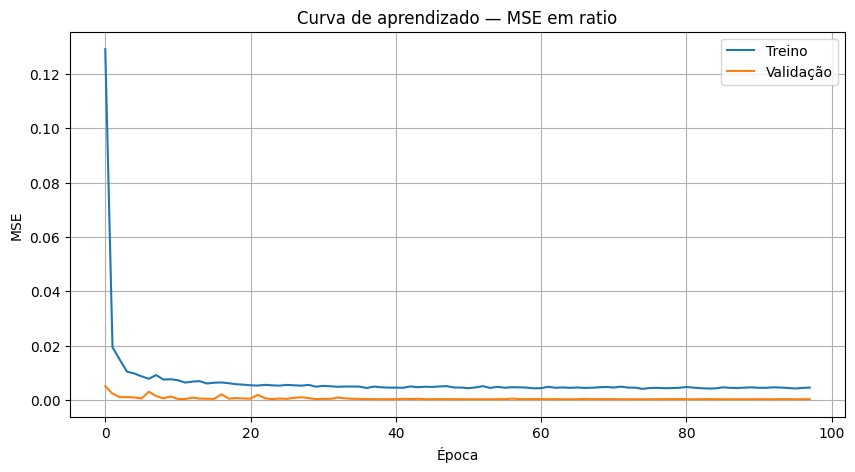

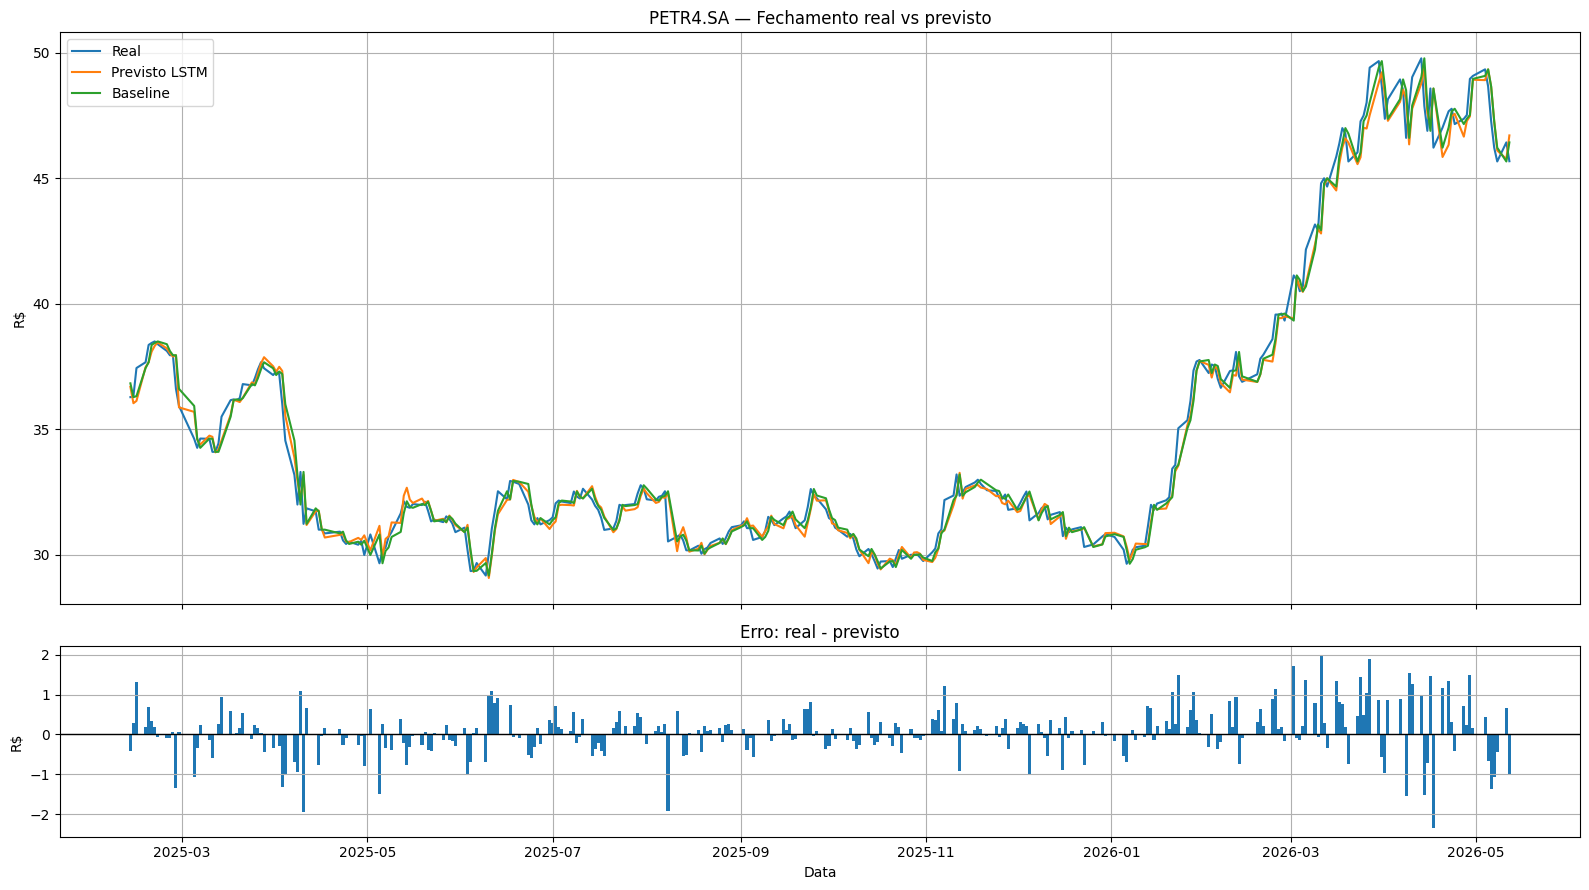

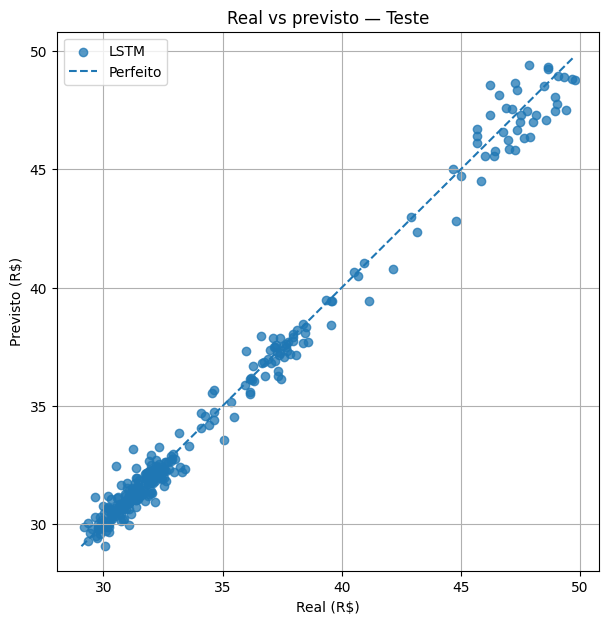

In [13]:
# Curva de aprendizado
plt.figure(figsize=(10, 5))
plt.plot(history["train"], label="Treino")
plt.plot(history["val"], label="Validação")
plt.title("Curva de aprendizado — MSE em ratio")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()

# Real vs previsto
plot_dates = pd.to_datetime(dates_test)

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

axes[0].plot(plot_dates, true_test_close, label="Real")
axes[0].plot(plot_dates, pred_test_close, label="Previsto LSTM")
axes[0].plot(plot_dates, baseline_test_close, label="Baseline")
axes[0].set_title(f"{SYMBOL} — Fechamento real vs previsto")
axes[0].set_ylabel("R$")
axes[0].legend()
axes[0].grid(True)

error = true_test_close - pred_test_close
axes[1].bar(plot_dates, error, width=1.0)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Erro: real - previsto")
axes[1].set_ylabel("R$")
axes[1].set_xlabel("Data")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Scatter real vs previsto
plt.figure(figsize=(7, 7))
plt.scatter(true_test_close, pred_test_close, alpha=0.75, label="LSTM")
min_v = min(true_test_close.min(), pred_test_close.min())
max_v = max(true_test_close.max(), pred_test_close.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--", label="Perfeito")
plt.title("Real vs previsto — Teste")
plt.xlabel("Real (R$)")
plt.ylabel("Previsto (R$)")
plt.legend()
plt.grid(True)
plt.show()

## 11. Salvamento dos artefatos

São salvos:

- pesos do modelo;
- scaler das features estacionárias;
- metadados da pipeline;
- métricas finais;
- amostra de previsões no teste.

In [14]:
def to_json_safe(obj):
    if isinstance(obj, dict):
        return {k: to_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_json_safe(v) for v in obj]
    if isinstance(obj, tuple):
        return [to_json_safe(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, pd.Timestamp):
        return obj.isoformat()
    return obj

model_path = ARTIFACT_DIR / "model_state_dict.pt"
preprocess_path = ARTIFACT_DIR / "preprocess.joblib"
metadata_path = ARTIFACT_DIR / "metadata.json"
metrics_path = ARTIFACT_DIR / "metrics.json"
predictions_path = ARTIFACT_DIR / "test_predictions.csv"

torch.save(model.state_dict(), model_path)

preprocess = {
    "scaler_stat": scaler_stat,
    "price_cols": PRICE_COLS,
    "stat_cols": STAT_COLS,
    "features": FEATURES,
    "window_size": WINDOW_SIZE,
}
joblib.dump(preprocess, preprocess_path)

metadata = {
    "symbol": SYMBOL,
    "start_date": START_DATE,
    "window_size": WINDOW_SIZE,
    "train_ratio": TRAIN_RATIO,
    "val_ratio": VAL_RATIO,
    "test_ratio": TEST_RATIO,
    "train_end_row": train_end,
    "val_end_row": val_end,
    "features": FEATURES,
    "price_cols": PRICE_COLS,
    "stat_cols": STAT_COLS,
    "model": {
        "input_size": X_train.shape[2],
        "hidden_size": HIDDEN_SIZE,
        "num_layers": NUM_LAYERS,
        "dropout": DROPOUT,
    },
    "train_info": train_info,
}

metrics = {
    "lstm_train": metrics_train,
    "lstm_val": metrics_val,
    "lstm_test": metrics_test,
    "baseline_test": metrics_baseline,
    "directional_accuracy_test_lstm_pct": lstm_direction,
    "directional_accuracy_test_baseline_pct": baseline_direction,
    "relative_gain_vs_baseline_pct": {
        k: (metrics_baseline[k] - metrics_test[k]) / metrics_baseline[k] * 100
        for k in ["mae", "rmse", "mape"]
    },
}

metadata_path.write_text(json.dumps(to_json_safe(metadata), indent=2, ensure_ascii=False), encoding="utf-8")
metrics_path.write_text(json.dumps(to_json_safe(metrics), indent=2, ensure_ascii=False), encoding="utf-8")

pred_df = pd.DataFrame({
    "date": pd.to_datetime(dates_test),
    "real_close": true_test_close,
    "pred_lstm_close": pred_test_close,
    "baseline_close": baseline_test_close,
    "error_lstm": true_test_close - pred_test_close,
    "abs_error_lstm": np.abs(true_test_close - pred_test_close),
    "pct_error_lstm": np.abs((true_test_close - pred_test_close) / true_test_close) * 100,
})
pred_df.to_csv(predictions_path, index=False)

print("Arquivos salvos em:", ARTIFACT_DIR.resolve())
print("-", model_path)
print("-", preprocess_path)
print("-", metadata_path)
print("-", metrics_path)
print("-", predictions_path)

Arquivos salvos em: H:\dev\fiap_tech_cha_fase4\src\models\petr4_lstm_v8
- models\petr4_lstm_v8\model_state_dict.pt
- models\petr4_lstm_v8\preprocess.joblib
- models\petr4_lstm_v8\metadata.json
- models\petr4_lstm_v8\metrics.json
- models\petr4_lstm_v8\test_predictions.csv


## 12. Função de inferência para futura API

A API pode receber um histórico recente de OHLCV, recalcular as features, montar a última janela e retornar a previsão do próximo fechamento.

Observação: para calcular médias móveis e volatilidade, envie mais linhas do que `WINDOW_SIZE`. Uma regra prática é enviar pelo menos `WINDOW_SIZE + 30` pregões.

In [15]:
def predict_next_close_from_ohlcv(
    recent_ohlcv: pd.DataFrame,
    model: nn.Module,
    preprocess: dict,
) -> dict:
    """Recebe OHLCV recente e retorna previsão do próximo fechamento.

    Espera colunas: Open, High, Low, Close, Volume.
    """
    df_recent = recent_ohlcv.copy()
    df_recent.index = pd.to_datetime(df_recent.index)
    df_recent = df_recent.sort_index()

    df_features = add_features(df_recent)

    window_size = preprocess["window_size"]
    price_cols = preprocess["price_cols"]
    stat_cols = preprocess["stat_cols"]
    scaler = preprocess["scaler_stat"]
    feature_cols = preprocess["features"]

    if len(df_features) < window_size:
        raise ValueError(f"Dados insuficientes após feature engineering. Necessário: {window_size}, recebido: {len(df_features)}")

    window_df = df_features.iloc[-window_size:]
    anchor_price = float(window_df["Close"].iloc[0])
    last_close = float(window_df["Close"].iloc[-1])

    window = window_df[feature_cols].values.astype(np.float64)
    price_idx = [feature_cols.index(c) for c in price_cols]
    stat_idx = [feature_cols.index(c) for c in stat_cols]

    window[:, price_idx] = window[:, price_idx] / anchor_price
    window[:, stat_idx] = scaler.transform(window[:, stat_idx])

    X = torch.tensor(window.reshape(1, window_size, len(feature_cols)), dtype=torch.float32).to(DEVICE)

    model.eval()
    with torch.no_grad():
        pred_ratio = float(model(X).cpu().numpy().reshape(-1)[0])

    predicted_close = pred_ratio * anchor_price

    return {
        "symbol": SYMBOL,
        "last_input_date": str(window_df.index[-1].date()),
        "last_close": last_close,
        "anchor_price": anchor_price,
        "predicted_ratio": pred_ratio,
        "predicted_close": predicted_close,
        "baseline_close": last_close,
    }

# Exemplo usando o próprio histórico disponível
preprocess_loaded = joblib.load(preprocess_path)
example_prediction = predict_next_close_from_ohlcv(df_raw.tail(WINDOW_SIZE + 60), model, preprocess_loaded)
example_prediction

{'symbol': 'PETR4.SA',
 'last_input_date': '2026-05-12',
 'last_close': 45.68000030517578,
 'anchor_price': 49.40999984741211,
 'predicted_ratio': 0.9251349568367004,
 'predicted_close': 45.71091807613698,
 'baseline_close': 45.68000030517578}

## 13. Conclusão sugerida para o relatório

> A LSTM foi treinada para prever o próximo fechamento da PETR4.SA usando uma janela temporal de preços e indicadores técnicos. Para reduzir problemas de escala e mudança de regime, os preços foram representados de forma relativa à primeira cotação da janela, enquanto retornos e indicadores foram padronizados com scaler ajustado apenas no conjunto de treino. A avaliação foi feita em dados de teste não usados no treinamento nem no early stopping, com comparação contra um baseline ingênuo baseado no último fechamento conhecido.

> Como séries financeiras são altamente ruidosas e influenciadas por variáveis externas, os resultados devem ser interpretados como demonstração técnica de uma pipeline de Machine Learning Engineering com LSTM, e não como recomendação financeira.